In [1]:
import copy
import salvus.namespace as sn
import numpy as np
import matplotlib.pyplot as plt 
import sys
import importlib
from pathlib import Path
for path_to_add in (Path.cwd(), Path.cwd() / "tomography"):
    if (path_to_add / "my_code").is_dir() and str(path_to_add) not in sys.path:
        sys.path.append(str(path_to_add))
import my_code.utilities
importlib.reload(my_code.utilities)
from my_code.utilities import *
import salvus
 
import salvus.mesh.layered_meshing as lm
from datetime import datetime
import salvus.flow.simple_config as sc
from salvus.toolbox.helpers.wavefield_output import (
    WavefieldOutput,
    wavefield_output_to_xarray,
)

import xarray as xr

--> Server: 'https://l.mondaic.com/licensing_server', User: 'bristol.support', Group: 'UniversityOfBristol'.
--> Negotiating 1 license instance(s) for 'SalvusMesh' [license version 1.0.0] for 1 seconds ...
--> Success! [Total duration: 0.51 seconds]


In [2]:
# ---- Salvus site --------------------------------------------------------
SITE_NAME = "isambard_oliver"
RANKS = 8

# ---- Physical parameters ------------------------------------------------
VP                = 1400.0
RHO               = 1025.0
THICKNESS           = 0.2   # m

alpha = 0.4  # thickness to wavelength ratio
f_c               = alpha * 25e3   # centre frequency [Hz]
CENTRAL_FREQUENCY = 0.8 * 25e3  # Hz




# ---- Domain -------------------------------------------------------------
x0, x1 = 0, 1
y0, y1 = 0, 2

# ---- Project ------------------------------------------------------------
PROJECT_DIR_WIN = '/home/b6as/oliverwfy.b6as/workspace/acoustic_model/Project'
DATA_DIR_WIN    = '/home/b6as/oliverwfy.b6as/workspace/acoustic_model/data'
IMAGE_DIR   = Path('/home/b6as/oliverwfy.b6as/workspace/acoustic_FWI_velocity_underwater/image')

Path(PROJECT_DIR_WIN).mkdir(parents=True, exist_ok=True)
Path(DATA_DIR_WIN).mkdir(parents=True, exist_ok=True)
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

PROJECT_NAME = f'TFM'
domain = sn.domain.dim2.BoxDomain(x0=x0, x1=x1, y0=y0, y1=y1)

p = sn.Project.from_domain(
    path=Path(PROJECT_DIR_WIN, PROJECT_NAME), domain=domain, load_if_exists=True
)

# ---- Mesh resolution ----------------------------------------------------
elements_per_wavelength = 3
model_order             = 4
reference_velocity      = VP
number_of_wavelengths   = 2
reference_frequency     = CENTRAL_FREQUENCY * 2
free_surfaces           =  False

# ---- True (layered) model -----------------------------------------------
m_true = sn.layered_meshing.LayeredModel([
    sn.material.from_params(rho=RHO, vp=1400),
    sn.layered_meshing.interface.Hyperplane.at(1.4),
    sn.material.from_params(rho=RHO, vp=1420),
    sn.layered_meshing.interface.Hyperplane.at(1.2),
    sn.material.from_params(rho=RHO, vp=1440),
    sn.layered_meshing.interface.Hyperplane.at(1.0),
    sn.material.from_params(rho=RHO, vp=1460),
    sn.layered_meshing.interface.Hyperplane.at(0.8),
    sn.material.from_params(rho=RHO, vp=1480),
    sn.layered_meshing.interface.Hyperplane.at(0.6),
    sn.material.from_params(rho=RHO, vp=1500),
])

# ---- Initial (starting) model — two-layer ---------------------------
m_homo = sn.material.from_params(rho=RHO, vp=1400)

ab_params = salvus.mesh.simple_mesh.basic_mesh.AbsorbingBoundaryParameters(
    free_surface=free_surfaces,
    number_of_wavelengths=number_of_wavelengths,
    reference_velocity=reference_velocity,
    reference_frequency=reference_frequency,
)

mesh_res = sn.MeshResolution(
    reference_frequency=reference_frequency,
    elements_per_wavelength=elements_per_wavelength,
    model_order=model_order,
)

mesh_homo = lm.mesh_from_domain(
    domain=domain,
    model=sn.layered_meshing.MeshingProtocol(m_homo, ab=ab_params),
    mesh_resolution=mesh_res,
)

mesh = lm.mesh_from_domain(
    domain=domain,
    model=sn.layered_meshing.MeshingProtocol(m_true, ab=ab_params),
    mesh_resolution=mesh_res,
)



Accordion(children=(HTML(value='\n                <head>\n                <style>\n                td {\n     …

[2026-07-29 22:45:59,477] INFO: Loading project from /home/b6as/oliverwfy.b6as/workspace/acoustic_model/Project/TFM.


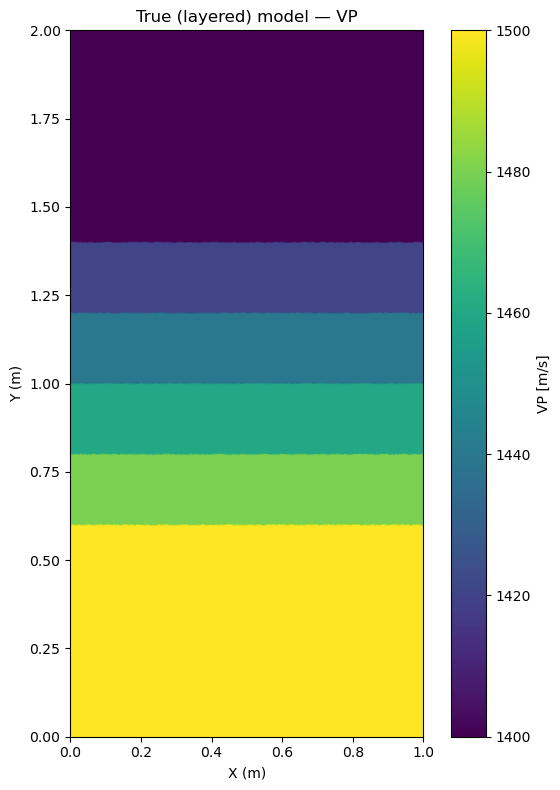

In [3]:
vp_nodal = elemental_nodal_to_nodal_field(mesh.element_nodal_fields['VP'], mesh.connectivity)

fig, ax = plt.subplots(figsize=(6, 8), dpi=100)
tp = ax.tripcolor(mesh.points[:, 0], mesh.points[:, 1], vp_nodal, cmap='viridis', shading='gouraud')
plt.colorbar(tp, ax=ax, label='VP [m/s]')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_title('True (layered) model — VP')
ax.set_xlim(x0, x1)
ax.set_ylim(y0, y1)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()


In [3]:
mesh_scatterers = mesh.copy()

rho_background = mesh_scatterers.elemental_fields["RHO"].copy()
scatterer_mask = np.zeros(rho_background.shape[0], dtype=bool)

scatterer_centers = [[0.3, 0.9],  [0.7, 1.1]]
scatterer_radius = 0.01

for scatterer_center in scatterer_centers:
    distance_from_scatterer = np.linalg.norm(
        mesh_scatterers.get_element_centroid() - scatterer_center,
        axis=1,
    )
    scatterer_mask |= distance_from_scatterer < scatterer_radius

mesh_scatterers.elemental_fields["RHO"] = rho_background - scatterer_mask[:, None] * 1000


mesh_homo_scatterers = mesh_homo.copy()

rho_background = mesh_homo_scatterers.elemental_fields["RHO"].copy()
scatterer_mask = np.zeros(rho_background.shape[0], dtype=bool)

scatterer_centers = [[0.3, 0.9], [0.7, 1.1]]
scatterer_radius = 0.02

for scatterer_center in scatterer_centers:
    distance_from_scatterer = np.linalg.norm(
        mesh_homo_scatterers.get_element_centroid() - scatterer_center,
        axis=1,
    )
    scatterer_mask |= distance_from_scatterer < scatterer_radius

mesh_homo_scatterers.elemental_fields["RHO"] = rho_background - scatterer_mask[:, None] * 1000






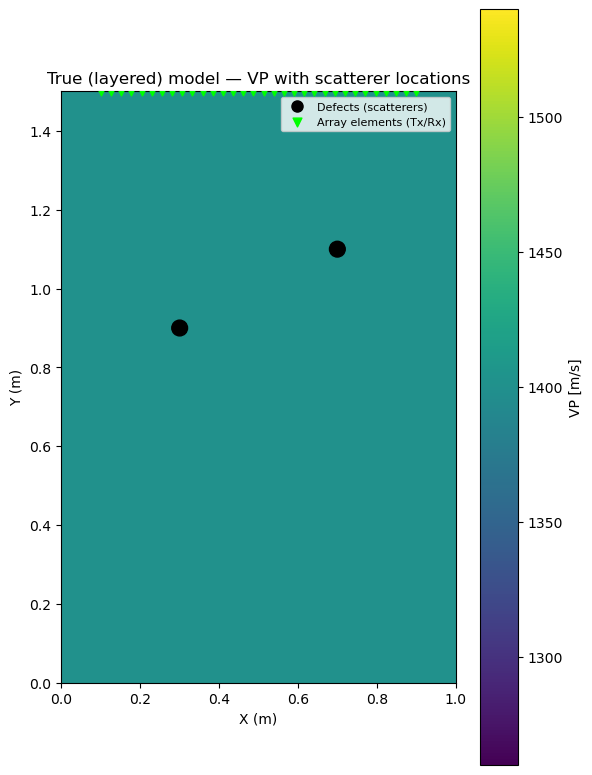

In [4]:
vp_nodal = elemental_nodal_to_nodal_field(
    mesh_homo_scatterers.element_nodal_fields['VP'], mesh_homo_scatterers.connectivity
)

n_elements = 32
array_x    = np.linspace(0.1, 0.9, n_elements)
array_loc  = [(x, 1.5) for x in array_x]

fig, ax = plt.subplots(figsize=(6, 8), dpi=100)
tp = ax.tripcolor(mesh_homo_scatterers.points[:, 0], mesh_homo_scatterers.points[:, 1],
                   vp_nodal, cmap='viridis', shading='gouraud')
plt.colorbar(tp, ax=ax, label='VP [m/s]')

for c in scatterer_centers:
    ax.add_patch(plt.Circle(c, scatterer_radius, facecolor='black',
                             edgecolor='black', linewidth=1.0, zorder=5))

array_handle = ax.scatter([e[0] for e in array_loc], [e[1] for e in array_loc],
                           marker='v', color='lime', s=40, zorder=6, label='Array elements (Tx/Rx)')

from matplotlib.lines import Line2D
defect_handle = Line2D([0], [0], marker='o', linestyle='none', markerfacecolor='black',
                        markeredgecolor='black', markersize=8, label='Defects (scatterers)')
ax.legend(handles=[defect_handle, array_handle], loc='upper right', fontsize=8)

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_title('True (layered) model — VP with scatterer locations')
ax.set_xlim(x0, x1)
ax.set_ylim(y0, 1.5)
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('homo_model_with_scatterers.png', dpi=300)
plt.show()

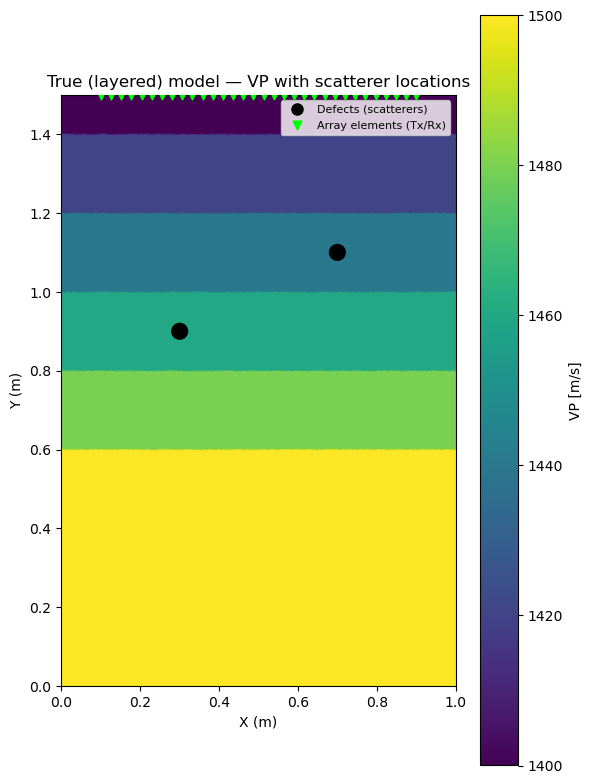

In [5]:

vp_nodal = elemental_nodal_to_nodal_field(
    mesh_scatterers.element_nodal_fields['VP'], mesh_scatterers.connectivity
)

n_elements = 32
array_x    = np.linspace(0.1, 0.9, n_elements)
array_loc  = [(x, 1.5) for x in array_x]

fig, ax = plt.subplots(figsize=(6, 8), dpi=100)
tp = ax.tripcolor(mesh_scatterers.points[:, 0], mesh_scatterers.points[:, 1],
                   vp_nodal, cmap='viridis', shading='gouraud')
plt.colorbar(tp, ax=ax, label='VP [m/s]')

for c in scatterer_centers:
    ax.add_patch(plt.Circle(c, scatterer_radius, facecolor='black',
                             edgecolor='black', linewidth=1.0, zorder=5))

array_handle = ax.scatter([e[0] for e in array_loc], [e[1] for e in array_loc],
                           marker='v', color='lime', s=40, zorder=6, label='Array elements (Tx/Rx)')

from matplotlib.lines import Line2D
defect_handle = Line2D([0], [0], marker='o', linestyle='none', markerfacecolor='black',
                        markeredgecolor='black', markersize=8, label='Defects (scatterers)')
ax.legend(handles=[defect_handle, array_handle], loc='upper right', fontsize=8)

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_title('True (layered) model — VP with scatterer locations')
ax.set_xlim(x0, x1)
ax.set_ylim(y0, 1.5)
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('true_model_with_scatterers.png', dpi=300)
plt.show()








In [ ]:
# ---- 8-element linear array: x in [0.1, 0.9], y = 1.6 -------------------
n_elements = 32
array_x    = np.linspace(0.1, 0.9, n_elements)
array_loc  = [(x, 1.5) for x in array_x]

amplitude_ratio = 1e4

# All 8 elements act as receivers for every transmit event
receivers = [
    sn.simple_config.receiver.cartesian.Point2D(
        x=r[0], y=r[1], station_code=f"R{j+1}", fields=["phi"]
    )
    for j, r in enumerate(array_loc)
]

# ---- Full matrix capture: one event per transmitting element ------------
event_ls = []
for i, s_loc in enumerate(array_loc):
    event_name = f'tx_{i}'
    source = sn.simple_config.source.cartesian.ScalarPoint2D(
        x=s_loc[0], y=s_loc[1], f=amplitude_ratio
    )
    p.add_to_project(
        sn.Event(event_name=event_name, sources=source, receivers=receivers)
    )
    event_ls.append(event_name)


In [ ]:
end_time               = 2e-3
start_time             = 0
sampling_rate_in_hertz = CENTRAL_FREQUENCY * 200
time_shift_in_seconds  = 1 / f_c

wavelet = sn.simple_config.stf.Ricker(
    center_frequency=f_c,
    time_shift_in_seconds=time_shift_in_seconds,
)

waveform_config = sn.WaveformSimulationConfiguration(
    start_time_in_seconds=start_time,
    end_time_in_seconds=end_time,
    time_step_in_seconds=1 / sampling_rate_in_hertz,
)

event_config = sn.EventConfiguration(
    wavelet=wavelet,
    waveform_simulation_configuration=waveform_config,
)

# # Homogeneous (starting) model
# p.add_to_project(
#     sn.UnstructuredMeshSimulationConfiguration(
#         unstructured_mesh=mesh_homo_scatterers,
#         name='forward_simulation_homogeneous_model',
#         event_configuration=event_config,
#     ),
#     overwrite=True,
# )



# p.add_to_project(
#     sn.UnstructuredMeshSimulationConfiguration(
#         unstructured_mesh=mesh_homo,
#         name='forward_simulation_homogeneous_model_reference',
#         event_configuration=event_config,
#     ),
#     overwrite=True,
# )


p.add_to_project(
    sn.UnstructuredMeshSimulationConfiguration(
        unstructured_mesh=mesh,
        name='forward_simulation_layred_model_reference',
        event_configuration=event_config,
    ),
    overwrite=True,
)

# True (layered) model — used to generate observed data
p.add_to_project(
    sn.UnstructuredMeshSimulationConfiguration(
        unstructured_mesh=mesh_scatterers,
        name='forward_simulation_layred_model',
        event_configuration=event_config,
    ),
    overwrite=True,
)

# p.viz.nb.simulation_setup(
#     simulation_configuration='forward_simulation_layred_model', events=event_ls
#     )

In [ ]:
def forward_simulation(simulation_name, events,
                       fields=None, sampling_interval_in_time_steps=10):
    if fields:
        p.simulations.launch(
            ranks_per_job=RANKS,
            site_name=SITE_NAME,
            events=events,
            simulation_configuration=simulation_name,
            extra_output_configuration={
                "volume_data": {
                    "sampling_interval_in_time_steps": sampling_interval_in_time_steps,
                    "fields": fields,
                },
            },
            delete_conflicting_previous_results=True,
        )
    else:
        p.simulations.launch(
            ranks_per_job=RANKS,
            site_name=SITE_NAME,
            events=events,
            simulation_configuration=simulation_name,
            delete_conflicting_previous_results=True,
        )

    p.simulations.query(block=True, verbosity=1)





def extract_data(simulation, events, receiver_field='phi', field=None):
    ed = p.waveforms.get(data_name=simulation, events=events)[0]
    data = ed.get_waveform_data_xarray(receiver_field=receiver_field)
    wavefield = None
    if field:
        wavefield = wavefield_output_to_xarray(
            ed.get_wavefield_output(output_type='volume', field=field),
            p.simulations.get_mesh(simulation).points,
        ).T
    return data, wavefield


def misfit_adjoint_source(u_obs, u, event=False, iteration=0):
    sampling_rate = u_obs.sampling_rate_in_hertz
    start_time    = u_obs.time[0]
    end_time      = u_obs.time[-1]

    diff   = u_obs - u
    misfit = 0.5 / sampling_rate * (diff ** 2).sum()
    f_adj  = np.flip(diff, axis=1) / sampling_rate

    event_adj        = None
    event_config_adj = None

    if event:
        rxs, srcs    = p.events.get(event).receivers, p.events.get(event).sources
        rxs_adj_loc  = [r.location for r in srcs]
        src_adj_loc  = [t.location for t in rxs]

        stf_adj_ls = [
            sc.stf.Custom.from_array(
                np.array(f_adj[i]),
                sampling_rate_in_hertz=sampling_rate_in_hertz,
                start_time_in_seconds=0.0,
            )
            for i in range(len(src_adj_loc))
        ]

        srcs_adj = [
            sn.simple_config.source.cartesian.ScalarPoint2D(x=tx[0], y=tx[1], f=1)
            for tx in src_adj_loc
        ]
        rxs_adj = [
            sn.simple_config.receiver.cartesian.Point2D(
                x=rx[0], y=rx[1],
                fields=['phi'],
                station_code=f"ite:{iteration}_adj_{_i:06d}",
            )
            for _i, rx in enumerate(rxs_adj_loc)
        ]

        event_adj = f'{event}_adjoint_{iteration}'
        p.add_to_project(sn.Event(event_name=event_adj, sources=srcs_adj, receivers=rxs_adj))

        event_config_adj = sn.EventConfiguration(
            wavelet=stf_adj_ls,
            waveform_simulation_configuration=sn.WaveformSimulationConfiguration(
                start_time_in_seconds=start_time,
                end_time_in_seconds=end_time,
                time_step_in_seconds=1 / sampling_rate_in_hertz,
            ),
        )

    return misfit, f_adj, event_adj, event_config_adj


def adjoint_wavefield(p, event_adj, event_config_adj,
                      model_simulation_name='forward_simulation_homogeneous_model',
                      field='phi_t', iteration=0,
                      sampling_interval_in_time_steps=10):
    simulation_adj  = f"adjoint_{iteration}"
    mesh_current    = p.simulations.get_mesh(model_simulation_name)

    p.add_to_project(
        sn.UnstructuredMeshSimulationConfiguration(
            unstructured_mesh=mesh_current,
            name=simulation_adj,
            event_configuration=event_config_adj,
        ),
        overwrite=True,
    )

    p.simulations.launch(
        ranks_per_job=RANKS,
        site_name=SITE_NAME,
        events=event_adj,
        simulation_configuration=simulation_adj,
        extra_output_configuration={
            "volume_data": {
                "sampling_interval_in_time_steps": sampling_interval_in_time_steps,
                "fields": [field],
            },
        },
        delete_conflicting_previous_results=True,
    )
    p.simulations.query(block=True, verbosity=1)


    _, wavefield_adj = extract_data(
        simulation=simulation_adj,
        events=event_adj,
        receiver_field='phi',
        field=field,
    )
    return wavefield_adj


def compute_gradient(forward_wavefield, adjoint_wavefield):
    """
    Sensitivity kernel K_A = ∂J/∂A  (zero-lag cross-correlation):

        K_A(x) = Σ_t φ†_t(x, T-t) · φ_t(x, t) · Δt

    φ† is time-reversed before the inner product because the adjoint
    simulation runs forward in time (source = time-reversed residual).

    Parameters
    ----------
    forward_wavefield : xarray   φ_t  shape (nodes, T)
    adjoint_wavefield : xarray   φ†_t    shape (nodes, T_adj)

    Returns
    -------
    K_A : np.ndarray, shape (n_nodes,)   ∂J/∂A
    """
    fwd = forward_wavefield.values.squeeze()    # (nodes, T)
    adj = adjoint_wavefield.values.squeeze()    # (nodes, T_adj)

    t_coord = forward_wavefield.coords.get('t', forward_wavefield.coords.get('time'))
    t_fwd   = t_coord.values
    dt      = float(t_fwd[1] - t_fwd[0])

    # Interpolate adjoint onto forward time axis if sampling strides differ
    if adj.shape[-1] != fwd.shape[-1]:
        from scipy.interpolate import interp1d
        t_adj = adjoint_wavefield.coords.get('t', adjoint_wavefield.coords.get('time')).values
        adj   = interp1d(t_adj, adj, axis=-1, kind='linear',
                         bounds_error=False, fill_value=0.0)(t_fwd)
                         

    # Time-reverse φ† → φ†(T-t), then dot with φ_tt(t)
    adj_flipped = np.flip(adj, axis=-1)                          # φ†(x, T-t)
    return np.einsum('nt,nt->n', adj_flipped, fwd) * dt          # (n_nodes,)

In [ ]:
t0 = datetime.now()

forward_simulation(
    simulation_name='forward_simulation_homogeneous_model_reference',
    events=event_ls,
    fields=None,
    sampling_interval_in_time_steps=20,
)


forward_simulation(
    simulation_name='forward_simulation_homogeneous_model',
    events=event_ls,
    fields=None,
    sampling_interval_in_time_steps=20,
)

elapsed = (datetime.now() - t0).total_seconds()
print(f"One simulation done in {int(elapsed//60)}m {elapsed%60:.1f}s")

In [ ]:
# phi, phi_wavefield = extract_data(
#     simulation='forward_simulation_homogeneous_model',
#     events=event_ls[2], receiver_field='phi', field=None)

# plt.plot(phi[1].time.values*1e3, phi[3].values)

In [ ]:
# ---- 8-element linear array: x in [0.1, 0.9], y = 1.6 -------------------
n_elements = 32
array_x    = np.linspace(0.1, 0.9, n_elements)
array_loc  = [(x, 1.5) for x in array_x]
scatterer_centers = [[0.3, 0.9],  [0.7, 1.1]]
scatterer_radius = 0.01

amplitude_ratio = 1e4
time_shift_in_seconds  = 1 / f_c


# ---- TFM reconstruction (full matrix capture, 16x16, constant c) ----------
# Background subtraction: for each event, subtract the no-scatterer reference
# signal ('forward_simulation_homogeneous_model_reference') from the main FMC
# signal ('forward_simulation_homogeneous_model') so only the defect-scattered
# energy (direct wave, reverberation, etc. removed) is imaged.
c = 1400.0   # assumed constant velocity [m/s]
db_floor = -4.0   # dynamic range floor for display [dB]

tx_locs = array_loc   # all 16 transmitting elements (one event each)
rx_locs = array_loc   # all 16 receiving elements per event

# Imaging grid — restricted to ROI
x0_roi, x1_roi = 0.0, 1.0
y0_roi, y1_roi = 0.6, 1.5

nx, ny = 300, 300
x_img = np.linspace(x0_roi, x1_roi, nx)
y_img = np.linspace(y0_roi, y1_roi, ny)
Xg, Yg = np.meshgrid(x_img, y_img)

from scipy.interpolate import interp1d
from scipy.signal import hilbert

tfm_image = np.zeros_like(Xg)                     # envelope-summed image
time_shift_per_source = np.zeros(len(tx_locs))    # measured Ricker delay, one per transmitting element

for i, tx_loc in enumerate(tx_locs):
    phi_i, _ = extract_data(
        simulation='forward_simulation_homogeneous_model',
        events=event_ls[i], receiver_field='phi', field=None)
    phi_ref_i, _ = extract_data(
        simulation='forward_simulation_homogeneous_model_reference',
        events=event_ls[i], receiver_field='phi', field=None)

    time_axis = phi_i.time.values                        # (n_time,)
    amp       = phi_i.values - phi_ref_i.values           # (n_receivers, n_time), background-subtracted
    envelope  = np.abs(hilbert(amp, axis=-1))             # analytic-signal envelope

    # Per-source time shift: peak arrival on the co-located receiver (element i),
    # i.e. zero travel distance, measured on the clean reference trace (no scatterer
    # echoes to confuse the pick) so this isolates the Ricker wavelet's built-in
    # delay for this specific source rather than assuming it is identical across sources.
    t_max_idx_i     = np.argmax(phi_ref_i[i].values)
    time_shift_i    = phi_ref_i.time.values[t_max_idx_i]
    time_shift_per_source[i] = time_shift_i
    print(f"tx_{i}: measured time shift = {time_shift_i*1e3:.4f} ms  "
          f"(theoretical = {time_shift_in_seconds*1e3:.4f} ms)")

    dist_tx = np.sqrt((Xg - tx_loc[0])**2 + (Yg - tx_loc[1])**2)

    for j, rx in enumerate(rx_locs):
        dist_rx = np.sqrt((Xg - rx[0])**2 + (Yg - rx[1])**2)
        tof = (dist_tx + dist_rx) / c + time_shift_i   # + this source's measured wavelet delay

        interp_fn = interp1d(time_axis, envelope[j], kind='linear',
                              bounds_error=False, fill_value=0.0)
        tfm_image += interp_fn(tof)

# ---- Convert to dB (relative to peak, clipped at the display floor) -----
tfm_db = 20.0 * np.log10(np.maximum(tfm_image, 1e-300) / tfm_image.max())
tfm_db = np.clip(tfm_db, db_floor, 0.0)

fig, ax = plt.subplots(figsize=(6, 8), dpi=100)
im = ax.pcolormesh(Xg, Yg, tfm_db, cmap='inferno', vmin=db_floor, vmax=0.0, shading='auto')
plt.colorbar(im, ax=ax, label='TFM amplitude (dB)')

for c_loc in scatterer_centers:
    ax.add_patch(plt.Circle(c_loc, scatterer_radius, fill=False,
                             edgecolor='cyan', linewidth=1.0, zorder=5))

ax.scatter([e[0] for e in array_loc], [e[1] for e in array_loc],
           marker='v', color='lime', s=40, zorder=6, label='Array elements (Tx/Rx)')

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_title(f'TFM image (dB) — background-subtracted FMC (16x16), c = {c:.0f} m/s')
ax.set_xlim(x0_roi, x1_roi)
ax.set_ylim(y0_roi, y1_roi)
ax.set_aspect('equal')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()


In [ ]:
# save the NxNxT FMC data in a xarray, with dimensions (n_tx, n_rx, n_time) and record time, sampling rate, element locations.
import re

def save_fmc_data(simulation_name, event_ls, array_loc, sampling_rate_in_hertz, data_dir):
    n_elements = len(array_loc)
    fmc_data    = None
    time_values = None

    for i, tx_event in enumerate(event_ls):
        phi_i, _ = extract_data(
            simulation=simulation_name,
            events=tx_event, receiver_field='phi', field=None)

        if fmc_data is None:
            time_values = phi_i.time.values
            fmc_data = np.zeros((n_elements, n_elements, time_values.size))

        # Map each trace back to its receiver index (R1 -> 0, R2 -> 1, ...) so the
        # rx axis lines up with array_loc regardless of trace ordering.
        rx_idx = [int(re.search(r"R(\d+)", rid).group(1)) - 1 for rid in phi_i.receiver_id.values]
        fmc_data[i, rx_idx, :] = phi_i.values

    tx_x = np.array([loc[0] for loc in array_loc])
    tx_y = np.array([loc[1] for loc in array_loc])

    fmc = xr.DataArray(
        fmc_data,
        dims=("tx", "rx", "time"),
        coords={
            "tx": np.arange(n_elements),
            "rx": np.arange(n_elements),
            "time": time_values,
            "tx_x": ("tx", tx_x),
            "tx_y": ("tx", tx_y),
            "rx_x": ("rx", tx_x),
            "rx_y": ("rx", tx_y),
        },
        attrs={"sampling_rate_in_hertz": sampling_rate_in_hertz},
        name="fmc",
    )

    fmc_path = Path(data_dir) / f"fmc_{simulation_name}.nc"
    fmc.to_netcdf(fmc_path)
    print(f"Saved FMC data {fmc.shape} to {fmc_path}")
    return fmc


sampling_rate_in_hertz = CENTRAL_FREQUENCY * 200

fmc = save_fmc_data(
    'forward_simulation_homogeneous_model', event_ls, array_loc,
    sampling_rate_in_hertz, DATA_DIR_WIN,
)
fmc_reference = save_fmc_data(
    'forward_simulation_homogeneous_model_reference', event_ls, array_loc,
    sampling_rate_in_hertz, DATA_DIR_WIN,
)


In [ ]:
# do the TFM reconstruction as before on the saved FMC data.
from scipy.interpolate import interp1d
from scipy.signal import hilbert

fmc_path           = Path(DATA_DIR_WIN) / "fmc_forward_simulation_homogeneous_model.nc"
fmc_reference_path = Path(DATA_DIR_WIN) / "fmc_forward_simulation_homogeneous_model_reference.nc"
fmc           = xr.open_dataarray(fmc_path)
fmc_reference = xr.open_dataarray(fmc_reference_path)

n_elements = fmc.sizes["tx"]
tx_locs    = list(zip(fmc.tx_x.values, fmc.tx_y.values))
rx_locs    = list(zip(fmc.rx_x.values, fmc.rx_y.values))
time_axis  = fmc.time.values

scatterer_centers = [[0.3, 0.9], [0.7, 1.1]]
scatterer_radius  = 0.01

c        = 1400.0   # assumed constant velocity [m/s]
db_floor = -4.0     # dynamic range floor for display [dB]

# Imaging grid — restricted to ROI
x0_roi, x1_roi = 0.0, 1.0
y0_roi, y1_roi = 0.6, 1.5

nx, ny = 300, 300
x_img = np.linspace(x0_roi, x1_roi, nx)
y_img = np.linspace(y0_roi, y1_roi, ny)
Xg, Yg = np.meshgrid(x_img, y_img)

tfm_image = np.zeros_like(Xg)                     # envelope-summed image
time_shift_per_source = np.zeros(n_elements)      # measured wavelet delay, one per transmitting element

for i, tx_loc in enumerate(tx_locs):
    # Background subtraction: remove the no-scatterer reference FMC so only the
    # defect-scattered energy (direct wave, reverberation, etc. removed) is imaged.
    amp      = fmc.isel(tx=i).values - fmc_reference.isel(tx=i).values   # (n_rx, n_time)
    envelope = np.abs(hilbert(amp, axis=-1))       # analytic-signal envelope

    # Per-source time shift: peak arrival on the co-located reference trace (tx == rx == i),
    # i.e. zero travel distance, measured on the clean reference (no scatterer echoes to
    # confuse the pick) so this isolates the source wavelet's built-in delay.
    ref_colocated = fmc_reference.isel(tx=i, rx=i).values
    t_max_idx_i   = np.argmax(ref_colocated)
    time_shift_i  = time_axis[t_max_idx_i]
    time_shift_per_source[i] = time_shift_i
    print(f"tx_{i}: measured time shift = {time_shift_i*1e3:.4f} ms")

    dist_tx = np.sqrt((Xg - tx_loc[0])**2 + (Yg - tx_loc[1])**2)

    for j, rx_loc in enumerate(rx_locs):
        dist_rx = np.sqrt((Xg - rx_loc[0])**2 + (Yg - rx_loc[1])**2)
        tof = (dist_tx + dist_rx) / c + time_shift_i   # + this source's measured wavelet delay

        interp_fn = interp1d(time_axis, envelope[j], kind='linear',
                              bounds_error=False, fill_value=0.0)
        tfm_image += interp_fn(tof)

# ---- Convert to dB (relative to peak, clipped at the display floor) -----
tfm_db = 20.0 * np.log10(np.maximum(tfm_image, 1e-300) / tfm_image.max())
tfm_db = np.clip(tfm_db, db_floor, 0.0)

fig, ax = plt.subplots(figsize=(6, 8), dpi=100)
im = ax.pcolormesh(Xg, Yg, tfm_db, cmap='inferno', vmin=db_floor, vmax=0.0, shading='auto')
plt.colorbar(im, ax=ax, label='TFM amplitude (dB)')

from matplotlib.lines import Line2D

for c_loc in scatterer_centers:
    ax.add_patch(plt.Circle(c_loc, 0.02, fill=False,
                             edgecolor='cyan', linewidth=1.0, zorder=8))

array_handle  = ax.scatter([t[0] for t in tx_locs], [t[1] for t in tx_locs],
                            marker='v', color='lime', s=40, zorder=6, label='Array elements (Tx/Rx)')
defect_handle = Line2D([0], [0], marker='o', linestyle='none', markerfacecolor='none',
                        markeredgecolor='cyan', markersize=8, label='Defects (scatterers)')

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_title(f'TFM image (dB), c = {c:.0f} m/s')
ax.set_xlim(x0_roi, x1_roi)
ax.set_ylim(y0_roi, y1_roi)
ax.set_aspect('equal')
ax.legend(handles=[defect_handle, array_handle], loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig(f"TFM_image_from_saved_FMC_data_c_{c:.0f}_m_s.png", dpi=300)
plt.show()